# 03b — IR metrics from first principles

**Phase 1.5, notebook 2 of 5.**

In `03a` we agreed: retrieval gives a ranked list, classification gives a label, and accuracy is the wrong question. Now we pick up the right tools.

By the end of this notebook you will:

1. Be able to **derive Recall@k, MRR, and AP by hand** from a single binary relevance vector.
2. Know **when each metric lies to you** (their blind spots) and which to deploy when.
3. Understand why we report **bootstrap confidence intervals**, not just means.
4. Have implementations ready to lift into `src/luki/eval/metrics.py`.

---

## Refresher — precision, recall, and what "rank" means

From the binary classification confusion matrix:

| | predicted: relevant | predicted: not relevant |
|---|---|---|
| **truly relevant** | TP | FN |
| **truly irrelevant** | FP | TN |

$$\text{Precision} = \frac{TP}{TP + FP} \quad\text{(of what I returned, how much was relevant?)}$$

$$\text{Recall} = \frac{TP}{TP + FN} \quad\text{(of what's relevant out there, how much did I return?)}$$

These two are in tension: lower the threshold → recall up, precision down. The classification F1 collapses both into one number.

**Retrieval changes the picture in one important way**: the system doesn't classify, it *ranks*. The output is an *ordered list*. So we no longer have one P/R pair — we have a P/R pair *at every cutoff k*. "Rank" is a position in that list (1-indexed), not a score. The metrics we'll meet are different ways of summarising the P/R behaviour across all k's, with different opinions about what matters.

**Why top-k truncation is a product decision, not a stats decision**: if the LUKI UI shows the user 10 thumbnails, then how the model ranks docs at positions 11–205 is *literally invisible to the user*. Reporting Recall@100 is statistically valid but product-irrelevant. The k you report is the k your UI shows.

## Setup

In [3]:
from __future__ import annotations

import sys
from pathlib import Path

REPO = Path().resolve().parent
sys.path.insert(0, str(REPO / "src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.set_printoptions(precision=3, suppress=True)
pd.set_option("display.max_colwidth", 80)

In [4]:
from luki.api import services
from luki.embeddings.dataset import load_image, resolve_path

manifest = pd.read_parquet(REPO / "data" / "processed" / "manifest.parquet")
RAW_DIR  = REPO / "data" / "raw"
store    = services.get_store()
embedder = services.get_embedder()
print(f"{len(manifest)} photos, {store.count()} Qdrant points")

# Manifest-keyed lookup: from a hit's relative_path, get its true relevance label.
# We use the manifest (not the Qdrant payload) as the source of truth for eval supervision.
path_to_roll = dict(zip(manifest["relative_path"], manifest["roll_tags"]))

c:\winhome\dev\luki\.venv\Lib\site-packages\qdrant_client\qdrant_remote.py:288: UserWarning: Failed to obtain server version. Unable to check client-server compatibility. Set check_compatibility=False to skip version check.
  show_warning(
Loading weights: 100%|██████████| 415/415 [00:00<00:00, 4865.95it/s]

205 photos, 205 Qdrant points


## A worked example by hand

We need *one* concrete query with a clean relevance vector to anchor every formula. Take the FILM query from `03a` (`roll='vzla|2'`): we know this roll has ~39 other photos, so Family A's relevance label is well-defined.

**The contract for every metric below**: input is a 1-D array `relevance ∈ {0, 1}^N` listing the relevance label of each returned doc *in ranked order*, plus a scalar `n_relevant` saying how many relevant docs exist in the corpus *in total* (which can exceed `sum(relevance)` if some relevant docs were ranked outside the cut).

> **Senior aside — decouple eval supervision from the production index.** Qdrant's payload carries only what we need for production filtering (`medium`, `camera`, `year`, etc.). Eval supervision is *richer*: we want any column the manifest has, including ones added later. (`roll_tags` was added to the manifest *after* embeddings were upserted, so it's missing from the Qdrant payload entirely — and that's fine.) The right move is to look up the relevance label from the **manifest**, keyed on `relative_path`. The production index stays lean; the eval is free to look anywhere. Interviewers love seeing this separation: production data layout and eval data layout serve different masters.

In [12]:
# Pick the FILM query, retrieve top-50 from Qdrant, label each hit by Family A (same roll_tags).
# Note: we look up roll_tags from the MANIFEST, keyed on relative_path — not from the Qdrant payload.
film_rolls = manifest[manifest["roll_tags"].notna()]["roll_tags"].value_counts()
query_row = manifest[manifest["roll_tags"] == film_rolls.index[0]].iloc[0]
query_roll = query_row["roll_tags"]

img = load_image(resolve_path(query_row["relative_path"], RAW_DIR))
qvec = embedder.embed([img])[0]

TOP_K = 50  # we'll ask for 50, evaluate at smaller cuts
raw = store.search(qvec, top_k=TOP_K + 1)  # +1 to drop self-match
hits = [h for h in raw if (h.payload or {}).get("file_hash") != query_row["file_hash"]][:TOP_K]

# Binary relevance vector — Family A: same roll_tags → relevant.
# We use path_to_roll (manifest-derived), not h.payload.get("roll_tags").
relevance = np.array([
    int(path_to_roll.get((h.payload or {}).get("relative_path")) == query_roll)
    for h in hits
], dtype=int)

# Total relevant in the corpus (excluding the query itself)
n_relevant = int(((manifest["roll_tags"] == query_roll) & (manifest["file_hash"] != query_row["file_hash"])).sum())

print(f"Query: {query_row['filename']}  (roll={query_roll!r})")
print(f"Total relevant in corpus: {n_relevant}")
print(f"Top-{TOP_K} relevance vector ({relevance.sum()} relevant retrieved):")
print(" ", relevance)
print()
print("Rank-of-relevant positions (1-indexed):", (np.where(relevance == 1)[0] + 1).tolist())

Query: 26_03_2026_0001-3.jpg  (roll='vzla|2')
Total relevant in corpus: 39
Top-50 relevance vector (11 relevant retrieved):
  [1 0 0 0 1 0 0 0 0 0 0 0 0 0 1 0 1 0 0 0 0 1 1 1 0 0 0 1 0 0 0 0 0 0 0 0 0
 1 0 0 0 1 0 0 0 0 0 1 0 0]

Rank-of-relevant positions (1-indexed): [1, 5, 15, 17, 22, 23, 24, 28, 38, 42, 48]


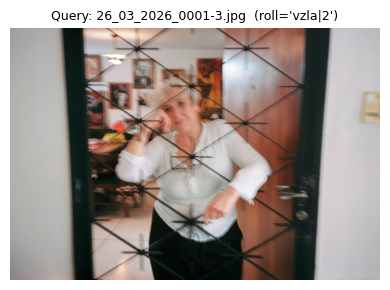

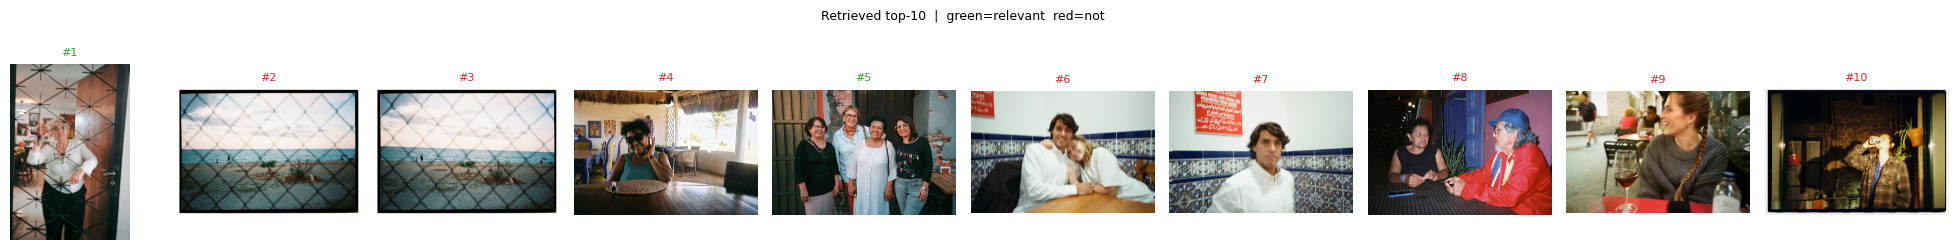

In [14]:
def show_image(row: pd.Series, title: str | None = None, ax=None) -> None:
    """Display a single manifest row's image inline."""
    img = load_image(resolve_path(row["relative_path"], RAW_DIR))
    standalone = ax is None
    if standalone:
        _, ax = plt.subplots(figsize=(4, 4))
    ax.imshow(img)
    ax.axis("off")
    ax.set_title(title or row["filename"], fontsize=9)
    if standalone:
        plt.tight_layout()
        plt.show()

def show_hits(hits, relevance: np.ndarray, n: int = 10) -> None:
    """Display the top-n retrieved images, green border = relevant, red = not."""
    n = min(n, len(hits))
    fig, axes = plt.subplots(1, n, figsize=(2 * n, 2.5))
    for i, (h, rel) in enumerate(zip(hits[:n], relevance[:n])):
        rel_path = (h.payload or {}).get("relative_path")
        row = manifest[manifest["relative_path"] == rel_path]
        if not row.empty:
            img = load_image(resolve_path(rel_path, RAW_DIR))
            axes[i].imshow(img)
        axes[i].axis("off")
        color = "#2ca02c" if rel else "#d62728"
        for spine in axes[i].spines.values():
            spine.set_edgecolor(color); spine.set_linewidth(3); spine.set_visible(True)
        axes[i].set_title(f"#{i+1}", fontsize=8, color=color)
    plt.suptitle("Retrieved top-10  |  green=relevant  red=not", fontsize=9)
    plt.tight_layout()
    plt.show()

show_image(query_row, title=f"Query: {query_row['filename']}  (roll={query_roll!r})")
show_hits(hits, relevance, n=10)

**Read the array yourself before continuing.** It tells you, for this query:
- Where the relevant docs landed in the ranking (positions of `1`s).
- How many landed in the top-50 (`relevance.sum()`) vs how many exist in total (`n_relevant`).
- The shape of failure: are the misses clustered at the bottom (model degrades gracefully) or scattered (model is inconsistent)?

Now we'll define each metric, derive its number on this exact array, and discuss when it lies.

## Recall@k — the user-facing metric

$$\text{Recall@}k = \frac{\#\text{relevant in top-}k}{\#\text{relevant in corpus}} = \frac{\sum_{i=1}^{k} \text{rel}_i}{n_{\text{relevant}}}$$

Reads as: *of all the relevant docs that exist, what fraction did I surface in the first k positions?*

**Why it's the most-reported metric for retrieval UIs**: it answers the user's question directly. *"Will what I'm looking for be on this page?"*

**Blind spot**: rank within the top-k is invisible. Recall@10 = 0.5 whether the 5 relevant docs landed at ranks 1-5 (great UX) or at ranks 6-10 (mediocre UX). To distinguish them you need either (a) report at multiple k's (Recall@1, @5, @10) or (b) use a rank-aware metric like AP.

In [29]:
def recall_at_k(relevance: np.ndarray, k: int, n_relevant: int) -> float:
    """Fraction of all relevant docs that landed in the top-k.

    relevance:  1-D binary array, ranked order.
    k:          cutoff (1-indexed; recall@1 looks at relevance[:1]).
    n_relevant: total relevant docs in the corpus.
    """

    if n_relevant == 0:
        return float("nan")  # query has no relevant docs — eval is undefined
    
    print(f"float({np.sum(relevance[:k])} / {n_relevant}): {float(np.sum(relevance[:k]) / n_relevant):.3f}")
    return float(np.sum(relevance[:k]) / n_relevant)


print(f"relevance: {relevance}, n_relevant: {n_relevant}")
for k in [1, 5, 10, 20, 50]:
    r = recall_at_k(relevance, k, n_relevant)
    print(f"Recall@{k:2d} = {r:.3f}   ({int(np.sum(relevance[:k]))}/{n_relevant} relevant retrieved by rank {k})")
    print("-" * 60)

relevance: [1 0 0 0 1 0 0 0 0 0 0 0 0 0 1 0 1 0 0 0 0 1 1 1 0 0 0 1 0 0 0 0 0 0 0 0 0
 1 0 0 0 1 0 0 0 0 0 1 0 0], n_relevant: 39
float(1 / 39): 0.026
Recall@ 1 = 0.026   (1/39 relevant retrieved by rank 1)
------------------------------------------------------------
float(2 / 39): 0.051
Recall@ 5 = 0.051   (2/39 relevant retrieved by rank 5)
------------------------------------------------------------
float(2 / 39): 0.051
Recall@10 = 0.051   (2/39 relevant retrieved by rank 10)
------------------------------------------------------------
float(4 / 39): 0.103
Recall@20 = 0.103   (4/39 relevant retrieved by rank 20)
------------------------------------------------------------
float(11 / 39): 0.282
Recall@50 = 0.282   (11/39 relevant retrieved by rank 50)
------------------------------------------------------------


float(1 / 39): 0.026
float(1 / 39): 0.026
float(1 / 39): 0.026
float(1 / 39): 0.026
float(2 / 39): 0.051
float(2 / 39): 0.051
float(2 / 39): 0.051
float(2 / 39): 0.051
float(2 / 39): 0.051
float(2 / 39): 0.051
float(2 / 39): 0.051
float(2 / 39): 0.051
float(2 / 39): 0.051
float(2 / 39): 0.051
float(3 / 39): 0.077
float(3 / 39): 0.077
float(4 / 39): 0.103
float(4 / 39): 0.103
float(4 / 39): 0.103
float(4 / 39): 0.103
float(4 / 39): 0.103
float(5 / 39): 0.128
float(6 / 39): 0.154
float(7 / 39): 0.179
float(7 / 39): 0.179
float(7 / 39): 0.179
float(7 / 39): 0.179
float(8 / 39): 0.205
float(8 / 39): 0.205
float(8 / 39): 0.205
float(8 / 39): 0.205
float(8 / 39): 0.205
float(8 / 39): 0.205
float(8 / 39): 0.205
float(8 / 39): 0.205
float(8 / 39): 0.205
float(8 / 39): 0.205
float(9 / 39): 0.231
float(9 / 39): 0.231
float(9 / 39): 0.231
float(9 / 39): 0.231
float(10 / 39): 0.256
float(10 / 39): 0.256
float(10 / 39): 0.256
float(10 / 39): 0.256
float(10 / 39): 0.256
float(10 / 39): 0.256
float(1

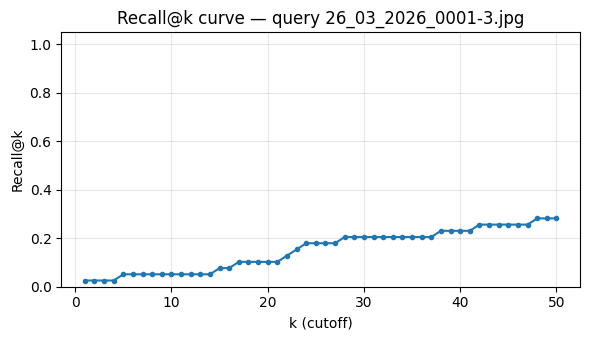

In [30]:
# Recall@k curve for this query — visualises the "how fast does the model surface relevant docs?" shape
ks = np.arange(1, TOP_K + 1)
recall_curve = np.array([recall_at_k(relevance, k, n_relevant) for k in ks])

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.plot(ks, recall_curve, marker="o", markersize=3)
ax.set_xlabel("k (cutoff)"); ax.set_ylabel("Recall@k")
ax.set_title(f"Recall@k curve — query {query_row['filename']}")
ax.set_ylim(0, 1.05); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

## MRR — the "first hit matters" metric

$$\text{RR} = \frac{1}{\text{rank of first relevant doc}}, \quad \text{MRR} = \frac{1}{|Q|}\sum_{q \in Q} \text{RR}_q$$

(MRR is the *mean* over queries; per-query the metric is RR. People sloppily say MRR for both.)

**When it's right**: search-style UX where the user clicks the first relevant result and stops. MRR rewards putting *one* relevant doc at the top; everything after that is invisible to it.

**Blind spot**: ignores the entire tail. RR = 1.0 whether you returned 1 relevant doc or 100. For a library exploration UX (where the user scrolls through several results), MRR is *deeply misleading* — it'll happily reward a system that gets one obvious neighbour right and butchers the rest.

**Note**: by convention, RR = 0 when no relevant doc is in the returned list at all.

In [31]:
def reciprocal_rank(relevance: np.ndarray) -> float:
    """1 / rank of the first relevant doc, or 0 if none in the list."""
    hits = np.where(relevance == 1)[0]
    if len(hits) == 0:
        return 0.0
    return float(1.0 / (hits[0] + 1))  # +1 because ranks are 1-indexed

rr = reciprocal_rank(relevance)
first_rank = int(np.where(relevance == 1)[0][0]) + 1 if relevance.any() else None
print(f"RR = {rr:.3f}   (first relevant at rank {first_rank})")

RR = 1.000   (first relevant at rank 1)


## Average Precision — the rank-aware metric for multi-relevant queries

AP is the trickiest of the three. The cleanest way to read it:

$$\text{AP} = \frac{1}{n_{\text{relevant}}} \sum_{k=1}^{N} P@k \cdot \text{rel}_k$$

Translated to English: walk down the ranked list. Every time you hit a relevant doc, write down the *precision so far* (P@k = #relevant up to rank k / k). At the end, average those numbers, and divide by the total number of relevant docs (so unretrieved relevants count as a 0).

**Why this shape**: it's implicitly area-under-the-precision-recall-curve. Each relevant doc encountered raises recall by `1/n_relevant`; the precision-at-that-moment is the height of the rectangle. AP = sum of rectangle areas under the P-R curve.

**When it's right**: you genuinely care about the *whole ranking* of relevant docs — library exploration, deduplication, anything where the user might scroll. AP penalises both "misses outside top-k" and "low-precision noise around the relevants."

**Blind spot**: hard to explain to a non-ML stakeholder. "Why did our number go from 0.62 to 0.58?" is harder to answer than for Recall@k.

**mAP** is just the mean of AP over a set of queries — same MRR-style abuse of language.

In [32]:
def average_precision(relevance: np.ndarray, n_relevant: int) -> float:
    """Standard IR average precision.

    relevance:   1-D binary array, ranked order.
    n_relevant:  total relevant in corpus (so unretrieved relevants count as 0).
    """
    if n_relevant == 0:
        return float("nan")
    cum_hits   = np.cumsum(relevance)             # running TP count at each rank
    ranks      = np.arange(1, len(relevance) + 1)
    precisions = cum_hits / ranks                 # P@k for every k
    return float(np.sum(precisions * relevance) / n_relevant)

ap = average_precision(relevance, n_relevant)
print(f"AP = {ap:.3f}")

# Walk it by hand for sanity. For each relevant doc, print its rank and the P@rank at that point.
print("\nBreakdown:")
cum = 0
contrib_sum = 0.0
for i, rel in enumerate(relevance, start=1):
    if rel == 1:
        cum += 1
        p_at_k = cum / i
        contrib_sum += p_at_k
        print(f"  rank {i:2d}: relevant.  P@{i} = {cum}/{i} = {p_at_k:.3f}")
missing = n_relevant - cum
print(f"  + {missing} relevant docs NOT in top-{TOP_K} → contribute 0 each")
print(f"  AP = {contrib_sum:.3f} / {n_relevant} = {contrib_sum / n_relevant:.3f}")

AP = 0.092

Breakdown:
  rank  1: relevant.  P@1 = 1/1 = 1.000
  rank  5: relevant.  P@5 = 2/5 = 0.400
  rank 15: relevant.  P@15 = 3/15 = 0.200
  rank 17: relevant.  P@17 = 4/17 = 0.235
  rank 22: relevant.  P@22 = 5/22 = 0.227
  rank 23: relevant.  P@23 = 6/23 = 0.261
  rank 24: relevant.  P@24 = 7/24 = 0.292
  rank 28: relevant.  P@28 = 8/28 = 0.286
  rank 38: relevant.  P@38 = 9/38 = 0.237
  rank 42: relevant.  P@42 = 10/42 = 0.238
  rank 48: relevant.  P@48 = 11/48 = 0.229
  + 28 relevant docs NOT in top-50 → contribute 0 each
  AP = 3.605 / 39 = 0.092


## Synthetic stress test — when each metric lies

Numbers in isolation are seductive. The way to *understand* a metric is to feed it adversarial cases and watch it break.

Four synthetic relevance vectors, each with the same `n_relevant = 5` total relevants and corpus size 50:

| Case | Pattern (top-10) | What a senior expects to see |
|---|---|---|
| **best** | `1 1 1 1 1 0 0 0 0 0` | All metrics maxed |
| **worst** | `0 0 0 0 0 1 1 1 1 1` (relevants at ranks 6-10) | Recall@10 still 1.0, RR=0.17, AP much lower |
| **mixed** | `1 0 1 0 1 0 1 0 1 0` | Recall same as best at k=10, but AP lower |
| **deep_miss** | `1 0 0 0 0 0 0 0 0 0`, plus 4 relevants at ranks 40-50 | RR=1.0, but AP and Recall@10 both poor |

If your intuition agrees with the table, you understand the metrics. If it doesn't, the plot below should fix that.

In [33]:
N_CORPUS = 50
N_REL = 5

def make_vec(positions: list[int]) -> np.ndarray:
    v = np.zeros(N_CORPUS, dtype=int)
    for p in positions:
        v[p - 1] = 1  # positions are 1-indexed
    return v

cases = {
    "best":      make_vec([1, 2, 3, 4, 5]),
    "worst":     make_vec([6, 7, 8, 9, 10]),
    "mixed":     make_vec([1, 3, 5, 7, 9]),
    "deep_miss": make_vec([1, 40, 45, 48, 50]),
}

rows = []
for name, v in cases.items():
    rows.append({
        "case":      name,
        "Recall@10": recall_at_k(v, 10, N_REL),
        "RR":        reciprocal_rank(v),
        "AP":        average_precision(v, N_REL),
    })
df = pd.DataFrame(rows).set_index("case")
df

float(5 / 5): 1.000
float(5 / 5): 1.000
float(5 / 5): 1.000
float(1 / 5): 0.200


,Recall@10,RR,AP
case,,,
best,1.0,1.000000,1.000000
worst,1.0,0.166667,0.354365
mixed,1.0,1.000000,0.678730
deep_miss,0.2,1.000000,0.260000


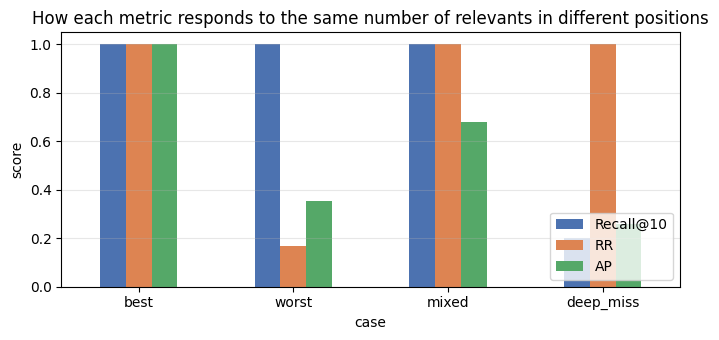

In [34]:
# Visualise: bar chart per case per metric. The point is to SEE where the metrics disagree.
fig, ax = plt.subplots(figsize=(7, 3.5))
df.plot.bar(ax=ax, rot=0, color=["#4c72b0", "#dd8452", "#55a868"])
ax.set_ylabel("score"); ax.set_ylim(0, 1.05); ax.grid(True, axis="y", alpha=0.3)
ax.set_title("How each metric responds to the same number of relevants in different positions")
ax.legend(loc="lower right")
plt.tight_layout(); plt.show()

**Read the chart**:

- `best` and `worst` have the **same Recall@10** (1.0) — Recall@k is rank-blind inside the cut.
- `best` and `mixed` have the **same Recall@10** (1.0) — same reason — but `mixed`'s AP is noticeably lower because precision dips between hits.
- `deep_miss` has **RR = 1.0** even though only 1 of 5 relevants made the top-10 — RR sees the first hit and stops looking.
- AP is the only one of the three that distinguishes all four cases. That's why it's the *default* answer in IR papers.

If you have to pick **one** number for an interview, AP is the senior choice. If you have to pick **one** number for a PM, Recall@10 is more legible. The right answer in the meeting is *"depends on the audience — here's both, and here's why they tell different stories."*

## All three on the real LUKI queries

Now apply the metrics to a handful of real queries (one per film roll) and look at the spread.

Watch what happens here — it's the most honest example of *why teaching multiple metrics matters*. You'll see the same model rated **excellent by RR**, **terrible by Recall@10**, and **modest by AP** — all simultaneously, all on the same queries. Each is correct; each is telling a different fact about the same system.

In [35]:
def evaluate_query(query_row: pd.Series, top_k: int = 50) -> dict:
    """Run one query, label each hit by Family A (manifest roll_tags), compute metrics."""
    img = load_image(resolve_path(query_row["relative_path"], RAW_DIR))
    qvec = embedder.embed([img])[0]
    raw = store.search(qvec, top_k=top_k + 1)
    hits = [h for h in raw if (h.payload or {}).get("file_hash") != query_row["file_hash"]][:top_k]
    rel = np.array([
        int(path_to_roll.get((h.payload or {}).get("relative_path")) == query_row["roll_tags"])
        for h in hits
    ], dtype=int)
    n_rel = int(((manifest["roll_tags"] == query_row["roll_tags"]) & (manifest["file_hash"] != query_row["file_hash"])).sum())
    return {
        "filename":   query_row["filename"],
        "roll":       query_row["roll_tags"],
        "n_relevant": n_rel,
        "Recall@10":  recall_at_k(rel, 10, n_rel),
        "Recall@20":  recall_at_k(rel, 20, n_rel),
        "RR":         reciprocal_rank(rel),
        "AP":         average_precision(rel, n_rel),
    }

# One representative query from each film roll
film_query_rows = [
    manifest[manifest["roll_tags"] == roll].iloc[0]
    for roll in manifest[manifest["roll_tags"].notna()]["roll_tags"].unique()
]
results = pd.DataFrame([evaluate_query(r) for r in film_query_rows])
results

float(2 / 36): 0.056
float(4 / 36): 0.111
float(2 / 36): 0.056
float(3 / 36): 0.083
float(2 / 35): 0.057
float(4 / 35): 0.114
float(4 / 35): 0.114
float(6 / 35): 0.171
float(2 / 39): 0.051
float(4 / 39): 0.103


,filename,roll,n_relevant,Recall@10,Recall@20,RR,AP
0,04_10_2025_0001.jpg,sombrilla|playa,36,0.055556,0.111111,1.0,0.052395
1,000003580001.jpg,paloma|salsa,36,0.055556,0.083333,1.0,0.057973
2,22_12_2025_0001.jpg,monserrat,35,0.057143,0.114286,1.0,0.124861
3,26_03_2026_0041.jpg,vzla|1,35,0.114286,0.171429,1.0,0.139698
4,26_03_2026_0001-3.jpg,vzla|2,39,0.051282,0.102564,1.0,0.092434


**This is the lesson of the whole notebook in one table.**

If you're seeing roughly:
- `RR ≈ 1.0` for every query — the very first hit (after the query itself) is *always* a roll-mate. Pick MRR as your metric and DINOv3 looks like a gold-medal model.
- `Recall@10 ≈ 0.05` — only ~2 of 10 displayed thumbnails are roll-mates. Pick Recall@10 and the same model looks barely functional.
- `AP ≈ 0.05–0.15` — the rank-aware truth: the model finds *one* roll-mate at the top, then drifts to other rolls.

**All three numbers are correct.** They describe the same ranked list. They diverge because they're asking different questions:
- *RR*: "is the very first thing right?" → yes.
- *Recall@10*: "of all roll-mates, how many fit on the page?" → few, because rolls have ~36 photos and only 10 fit.
- *AP*: "how cleanly is the whole ranking organised?" → modestly, because after the first hit the model surfaces *visually similar* photos that happen to live in different rolls.

**The thing to notice**: this isn't a model failure — it's an eval/product mismatch. If your product is *"give me one similar photo"*, this model is excellent. If your product is *"surface my whole roll"*, this model is mediocre. **Eval = product spec, again.** This is the same lesson as `03a` Part 3, now visible in actual numbers.

Look at the spread *across rolls*, not just the means — some rolls are easier than others. Reporting only `results.mean()` hides that. This is exactly why we need confidence intervals.

## Reporting uncertainty — bootstrap CIs

**Why "mean ± std" is a lazy answer**: per-query metrics are bounded in [0, 1] and often skewed. The Gaussian approximation underlying ±std reports symmetric error bars even when the actual distribution is one-sided. With only ~5 queries here, the std is also a *very* noisy estimate of the std itself.

**Bootstrap is the senior default**: resample your query results *with replacement* to get a synthetic distribution of the *mean*; report the 2.5%/97.5% quantiles of that distribution as a 95% CI. No normality assumption, no symmetry, and the procedure works for medians, ratios, or any other estimator you can imagine.

Procedure in plain words:
1. Take your N per-query AP values.
2. Sample N of them *with replacement* to get a bootstrap sample.
3. Compute the mean of that sample.
4. Repeat 10,000 times.
5. The distribution of those 10,000 means is your sampling distribution. Take the 2.5% and 97.5% percentiles.

**Caveat**: bootstrap doesn't manufacture data you don't have. With 5 queries the CI will be wide. That width is honest — narrowing it requires more queries, not a different statistical trick.

In [36]:
def bootstrap_ci(values: np.ndarray, n_boot: int = 10_000, alpha: float = 0.05, seed: int = 0) -> tuple[float, float, float]:
    """Returns (mean, lo, hi) for the mean of `values` with a 1-alpha CI."""
    rng = np.random.default_rng(seed)
    n = len(values)
    boots = np.array([rng.choice(values, size=n, replace=True).mean() for _ in range(n_boot)])
    lo, hi = np.quantile(boots, [alpha / 2, 1 - alpha / 2])
    return float(values.mean()), float(lo), float(hi)

for col in ["Recall@10", "Recall@20", "RR", "AP"]:
    m, lo, hi = bootstrap_ci(results[col].to_numpy())
    print(f"{col:10s} = {m:.3f}   95% CI [{lo:.3f}, {hi:.3f}]   width={hi-lo:.3f}")

Recall@10  = 0.067   95% CI [0.053, 0.091]   width=0.037
Recall@20  = 0.117   95% CI [0.095, 0.146]   width=0.051
RR         = 1.000   95% CI [1.000, 1.000]   width=0.000
AP         = 0.093   95% CI [0.063, 0.124]   width=0.062


**Read the widths.** With only 5 queries those CIs are *wide* — which is the whole point. You shouldn't be making model-comparison claims off 5 queries; the bootstrap forces that humility into the reported number. In `03d` we'll expand the eval set to all film photos with held-out queries and watch the CIs tighten.

---

## Senior questions you can defend now

1. **"mAP vs NDCG — when would you use one over the other?"**  
   AP/mAP assumes binary relevance. NDCG handles graded relevance (e.g. 0/1/2/3 — "perfect / good / okay / off-topic"). Use NDCG when you have graded judgments (search engines often do). Use mAP when relevance is binary, as it is here. NDCG also has a built-in rank discount via the log term, which is more aggressive than AP's; some people find it more interpretable.

2. **"Your Recall@10 is 0.85. What does that *not* tell the PM?"**  
   It doesn't say *where in the top-10* the relevants landed (rank-blind). It doesn't say what fraction of the *displayed* slots were relevant (that's precision, not recall). It doesn't say anything about the cohorts the metric couldn't judge (the digital coverage gap from 03a — and is it averaged over a sensible cohort, or did the bad cohort silently drop out?). And it doesn't quantify uncertainty — without a CI, 0.85 vs 0.83 is meaningless.

3. **"Why bootstrap CI and not std?"**  
   Per-query metrics are bounded and often skewed; std assumes Gaussianity it doesn't have. With small N the std-of-the-std is itself huge. Bootstrap makes no distributional assumption and works for any estimator (mean, median, ratio).

4. **"Why report at multiple ks?"**  
   A single Recall@k can't distinguish *steep early surfacing* from *gradual late surfacing* — both can produce the same number at one k. The Recall@k *curve* is the shape of the result; reporting (1, 5, 10, 20) samples it. Plus, different downstream UIs cut at different ks, and your eval should respect that.

5. **"You ran 5 queries. Convince me the result generalises."**  
   I haven't, and the CI width says so out loud. Five queries is a sanity check, not an evaluation. In `03d` we'll lift to a held-out set across all film photos. The point of this notebook is to lock down the *measurement* before scaling the *measured*.

6. **"Your RR is 1.0 and your Recall@10 is 0.05 on the same queries. Which one represents 'how good the model is'?"**  
   Neither — they represent two different *product questions*. RR is right if the user wants "one similar photo, fast." Recall@10 is right if the user wants "surface the whole roll." The eval is a question; the metric is the question's grammar. The first thing a senior asks before picking a metric is *what is the user trying to do?*

---

## What we'll productivize next

The three metric functions above (`recall_at_k`, `reciprocal_rank`, `average_precision`) plus the bootstrap helper are exactly what gets lifted into `src/luki/eval/metrics.py`. Same code, plus docstrings and unit tests with hand-crafted rank lists where the answer is obvious. That's the next concrete step — say the word and I'll do it.